# The Super Bowl guacamole trade 🥑
### Americans eat ~100 million pounds of avocados for the big game — is there a trade in it?

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Guacamole_surge%3F: Busted](https://img.shields.io/badge/Guacamole_surge%3F-Busted-8b949e?style=flat-square)

Every year around late January the stat makes the rounds: the U.S. imports a *mountain* of avocados for Super Bowl Sunday, more guacamole is eaten that weekend than any other, growers ship record volume. So the folk-finance leap is irresistible: if demand spikes on a **calendar date everyone can see coming**, the avocado / produce trade should carry a **January–February seasonal**. Buy ahead of the game, ride the surge.

This notebook takes that seriously and then takes it apart — with the avocado price's own seasonal shape, a real stock tape, and the one test that kills most calendar folklore: a **placebo** that asks whether the Super-Bowl window is actually special, or just one of sixty-six ordinary pairs of months.

> 📓 **Plain-language layer.** Want the *t*-stats, the Newey-West alpha and the placebo distribution? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice — and a data note.** The pure-play avocado stock (Calavo, `CVGW`) is currently **untradable on the Yahoo feed** (its daily history returns a single bar), so the tradable leg here is **`PEP`** — PepsiCo, whose Frito-Lay arm *is* the Super-Bowl chip-and-dip complex (Tostitos + the branded dips) — a **labelled proxy**. The avocado price line is a **small, cited, approximate** reconstruction of public USDA / Hass Avocado Board seasonality — a **proxy**, shown for its shape, never as a live feed.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath(os.path.join("..", "..", "..")))  # repo root (quantlab)
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"
MONTH_NAMES = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

from guacamole_bowl import data, strategy as st
try:
    from quantlab import repro
    D = repro.as_of(data.fetch_data())            # cache-first, pinned to the desk as-of
except Exception:
    D = data.fetch_data()
HAVE = not D.empty
AV = data.load_avocado_seasonal()                 # hardcoded, cited, APPROXIMATE proxy (shape only)
print("real-tape cache present:", HAVE, "| months:", (len(D) if HAVE else 0))

# frozen headline numbers (mirror of docs/results.md)
R = {'win': '1993-02 -> 2026-05', 'n_months': 400, 'asof': '2026-06-01', 'fp': '14fdb930823d', 'av_seasonal': {1: 95, 2: 97, 3: 100, 4: 103, 5: 102, 6: 105, 7: 110, 8: 114, 9: 111, 10: 103, 11: 93, 12: 90}, 'av_win_mean': 96.0, 'av_year_mean': 101.9, 'av_gap': -5.9, 'months': {1: (-0.38, -0.38, -0.36, 33), 2: (0.09, 0.1, 0.12, 34), 3: (2.69, 2.96, 3.53, 34), 4: (0.83, 0.94, 1.09, 34), 5: (1.08, 1.34, 1.23, 34), 6: (0.56, 0.63, 0.64, 33), 7: (1.1, 1.34, 1.44, 33), 8: (-1.51, -1.28, -0.94, 33), 9: (1.02, 1.14, 1.07, 33), 10: (2.55, 2.16, 1.95, 33), 11: (1.42, 1.98, 2.3, 33), 12: (0.62, 0.9, 1.06, 33)}, 'win_mean': -0.14, 'rest_mean': 1.04, 'spread': -1.19, 'spread_t': -1.67, 'n_win': 67, 'n_rest': 333, 'placebo_rank': 9, 'placebo_n': 66, 'placebo_pct': 14, 'placebo_z': -1.32, 'most_pos': [('Mar-Oct', 2.14), ('Mar-Nov', 1.47), ('Oct-Nov', 1.37)], 'ci_lo': -2.61, 'ci_hi': 0.26, 'ci_point': -1.19, 'timer_cagr': 1.5, 'timer_sharpe': -0.09, 'timer_mdd': -30, 'timer_net_cagr': 1.4, 'timer_net_sharpe': -0.11, 'pep_cagr': 8.7, 'pep_sharpe': 0.42, 'pep_mdd': -36, 'pep_vol': 18.4, 'pep_sharpe_raw': 0.54, 'spy_cagr': 10.9, 'spy_sharpe': 0.61, 'spy_mdd': -51, 'spy_vol': 14.8, 'spy_sharpe_raw': 0.77, 'nw_alpha': 3.46, 'nw_beta': 0.59, 'nw_t': 1.27, 'syn_spread': 3.7, 'syn_t': 4.6, 'syn_rank': 66, 'syn_timer': 0.65, 'syn_bh': -0.16, 'syn_null_spread': 0.1, 'syn_null_t': 0.12}


real-tape cache present: True | months: 400


## The answer first

| Question | Answer |
|---|---|
| Is the guacamole binge real? | **Yes.** The Super-Bowl avocado-volume spike is a genuine, well-documented demand event. |
| Does it lift the avocado *price* in Jan–Feb? | **No — the opposite.** Winter is the *soft* part of the avocado price year (heavy Mexican supply): the guac window sits **-6 index points below** the annual average. The surge is pre-supplied. |
| Does the trade show a Jan–Feb seasonal? | **No — it's the year's *weakest* window.** Jan–Feb underperforms the rest of the year by **-1.2%/month** (*t* = -1.67, wrong sign), ranking **9/66** among all month-pairs — near the bottom, not the top. |
| Could you trade it? | **No.** A long-Jan–Feb timer earns **Sharpe -0.09** vs buy-and-hold SPY's **0.61** — it puts you in the market only during the worst stretch of the year. |

> The binge is real. The *trade* is not — the calendar everyone can see is exactly why there's nothing left to harvest.

## 1 · The claim

> *"More guacamole is eaten on Super Bowl Sunday than any other day of the year — growers ship a record wall of Hass avocados for it. A demand spike that big, on a date you can circle in advance, has to move the avocado and produce trade. Buy in January, sell after the game."*

It's a *steelman-able* claim. The volume is real: the U.S. consumes on the order of **100+ million pounds** of avocados around the game, and importers/retailers visibly pre-position for it. Cinco de Mayo is a second, smaller guac holiday. If any consumer seasonal should be legible in a price, a nationally-televised, date-certain binge is the candidate.

## 2 · So what?

A clean, tradable calendar seasonal would be a small miracle: a known date, a known demand spike, a repeatable long window — the easiest kind of edge to run, no forecasting required. It's the same dream as *sell-in-May*, the *Santa-Claus rally*, or the coffee *frost trade*: pin your entries and exits to the calendar and get paid. But *"a lot of guacamole is eaten in February"* and *"the avocado trade goes up in February"* are very different statements. The first is about **demand volume**; the second is a claim about **price**, net of a supply chain that has months of warning. We can check the second directly.

## 3 · How would we even know?

Three honest looks:

1. **The avocado price's own shape.** Put the (cited, approximate) wholesale-Hass seasonal index on a chart. Does winter — the guac window — actually sit *high*?
2. **The tradable tape.** Take the Super-Bowl snack proxy (`PEP` / Frito-Lay) back to 1993 and line up every calendar month. Is Jan–Feb reliably strong?
3. **The placebo.** Score the Jan–Feb window against **all 66 pairs of months**. A real seasonal sits in the extreme tail; folklore sits in the crowd.

**What would make us say "real trade"?** Jan–Feb positive with *t* ≥ 2, sitting near the *top* of the placebo, and a timer that beats buy-and-hold. Anything less is a binge with no trade attached.

## 4 · The teardown — let's actually look

**First: the avocado price's own seasonal shape.** If the Super Bowl lifted prices, winter would be a peak. Here's the (approximate, cited) wholesale-Hass seasonal index.

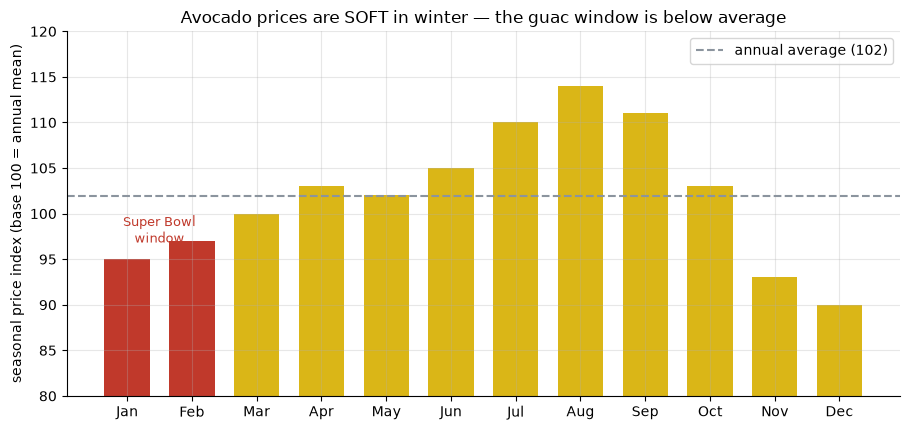

guac window (Jan-Feb) mean 96.0  vs annual mean 101.9  => -5.9 index pts


In [2]:
vals = [float(AV.loc[m]) for m in range(1,13)]
ymean = float(AV.mean())
fig, ax = plt.subplots(figsize=(9.2, 4.4))
cols = [RED if m in (1,2) else AMBER for m in range(1,13)]
ax.bar(MONTH_NAMES, vals, color=cols, width=.7)
ax.axhline(ymean, ls='--', c=GREY, label=f'annual average ({ymean:.0f})')
ax.annotate('Super Bowl\nwindow', (0.5, vals[0]), textcoords='offset points',
            xytext=(0, 12), ha='center', color=RED, fontsize=9)
ax.set_ylabel('seasonal price index (base 100 = annual mean)')
ax.set_title('Avocado prices are SOFT in winter — the guac window is below average'); ax.legend()
ax.set_ylim(80, 120)
plt.tight_layout(); plt.show()
print(f"guac window (Jan-Feb) mean {np.mean(vals[:2]):.1f}  vs annual mean {ymean:.1f}  "
      f"=> {np.mean(vals[:2])-ymean:+.1f} index pts")

The window everyone circles is the year's **soft** patch, ~**6 points below** average. Why? The Mexican Hass harvest floods the market in winter and the trade *pre-positions* months ahead for a date it has known since last season. The real price peak is the **late-summer supply gap** (Aug), which has nothing to do with football. The demand is real; the price simply absorbs it.

**Now the tape.** Here's the average return of the Super-Bowl snack proxy (`PEP`) in each calendar month since 1993, with the guac window in red.

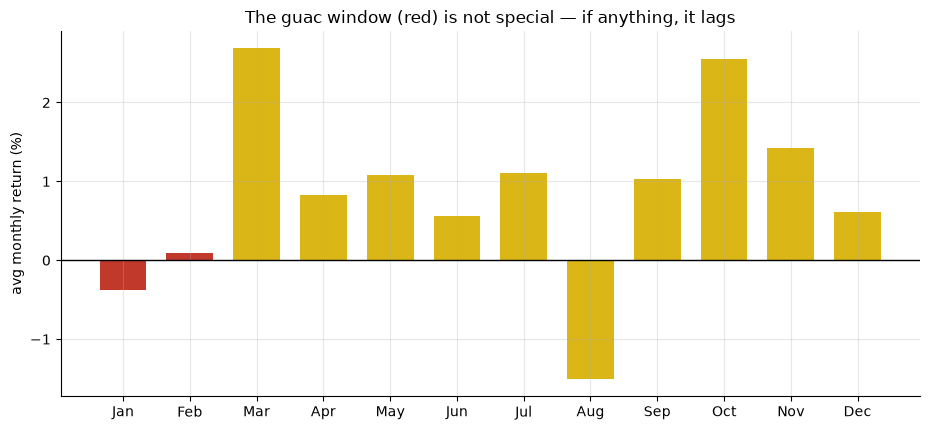

Jan: -0.38%  Feb: +0.09%  | best months are Mar/Oct/Nov (off-thesis)


In [3]:
if HAVE:
    ms = st.month_stats(D['pep'])
    means = [ms.loc[m,'mean']*100 for m in range(1,13)]
else:
    means = [R['months'][m][0] for m in range(1,13)]
cols = [RED if m in (1,2) else AMBER for m in range(1,13)]
fig, ax = plt.subplots(figsize=(9.4, 4.4))
ax.bar(MONTH_NAMES, means, color=cols, width=.7)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('avg monthly return (%)')
ax.set_title('The guac window (red) is not special — if anything, it lags'); 
plt.tight_layout(); plt.show()
print('Jan:', f"{means[0]:+.2f}%", ' Feb:', f"{means[1]:+.2f}%", ' | best months are Mar/Oct/Nov (off-thesis)')

January is **negative** (-0.38%) and February is a **flat +0.09%**. The genuinely strong months — March, October, November — have nothing to do with the Super Bowl. The window the folklore points at is, if anything, a *drag*.

**The placebo — is Jan–Feb even special?** We score the Super-Bowl window against every one of the 66 possible pairs of months. If the guac seasonal were real, Jan–Feb would sit at the far *right* (most positive). Where does it actually land?

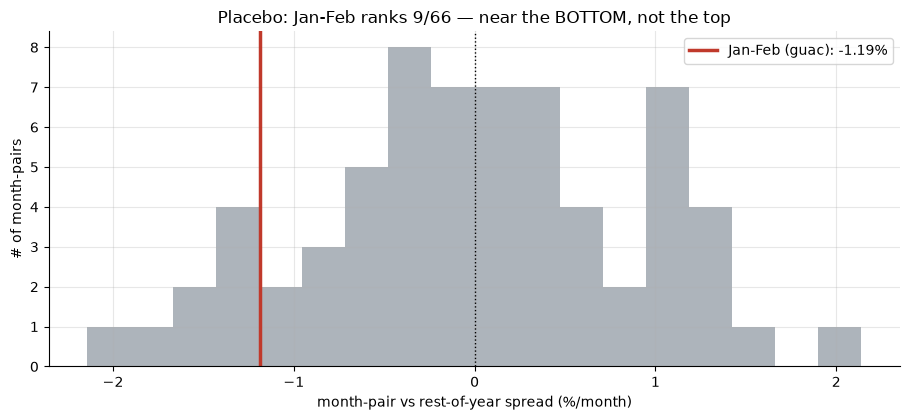

Jan-Feb spread -1.19%/mo ranks 9/66 (1=lowest). It is among the WEAKEST windows, not the strongest.


In [4]:
import itertools
if HAVE:
    pb = st.placebo_pairs(D['pep'])
    s = D['pep']; s.index = pd.DatetimeIndex(s.index)
    spreads = []
    for pair in itertools.combinations(range(1,13),2):
        w = s[s.index.month.isin(pair)]; r = s[~s.index.month.isin(pair)]
        spreads.append((w.mean()-r.mean())*100)
    jf = (s[s.index.month.isin([1,2])].mean()-s[~s.index.month.isin([1,2])].mean())*100
    rank = pb['rank']
else:
    spreads = list(np.random.default_rng(0).normal(0,0.9,66)); jf = R['spread']; rank = R['placebo_rank']
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.hist(spreads, bins=18, color=GREY, alpha=.7)
ax.axvline(jf, c=RED, lw=2.5, label=f'Jan-Feb (guac): {jf:+.2f}%')
ax.axvline(0, c='k', lw=1, ls=':')
ax.set_xlabel('month-pair vs rest-of-year spread (%/month)'); ax.set_ylabel('# of month-pairs')
ax.set_title(f'Placebo: Jan-Feb ranks {rank}/66 — near the BOTTOM, not the top'); ax.legend()
plt.tight_layout(); plt.show()
print(f"Jan-Feb spread {jf:+.2f}%/mo ranks {rank}/66 (1=lowest). It is among the WEAKEST windows, not the strongest.")

There it is. The Super-Bowl window ranks **9 out of 66** — in the bottom **14%** of all month-pairs. Dozens of *arbitrary* windows with no story beat it. A real seasonal lives in the tail; this one is buried in the crowd, on the wrong side of zero.

**Finally, could you trade it?** The obvious rule: hold the snack proxy in Jan–Feb, sit in T-bills the rest of the year. Race it against just buying and holding SPY.

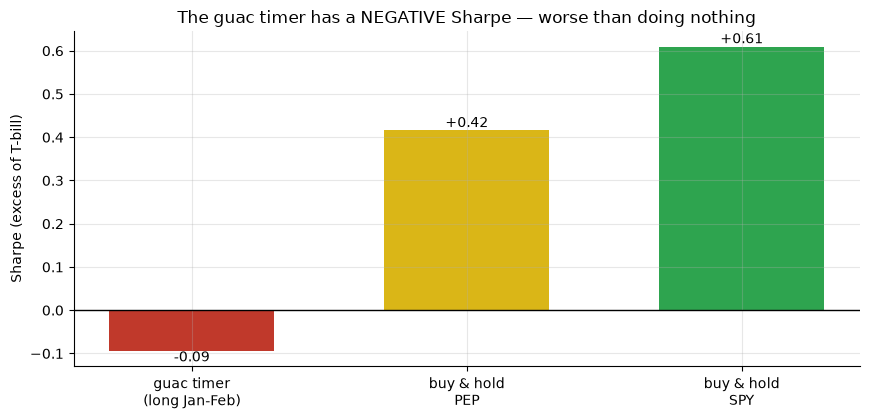

guac timer Sharpe -0.09  vs  buy-and-hold SPY +0.61


In [5]:
if HAVE:
    rf = D['tbill']
    timer = st.seasonal_timer(D['pep'], tbill=rf)
    bh_pep = st.buy_hold(D['pep']); bh_spy = st.buy_hold(D['spy'])
    rows = {'guac timer\n(long Jan-Feb)': st.summary(timer, rf=rf)['sharpe'],
            'buy & hold\nPEP': st.summary(bh_pep, rf=rf)['sharpe'],
            'buy & hold\nSPY': st.summary(bh_spy, rf=rf)['sharpe']}
else:
    rows = {'guac timer\n(long Jan-Feb)': R['timer_sharpe'], 'buy & hold\nPEP': R['pep_sharpe'], 'buy & hold\nSPY': R['spy_sharpe']}
labels=list(rows); vals=list(rows.values())
cols=[RED, AMBER, GREEN]
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.bar(labels, vals, color=cols, width=.6)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('Sharpe (excess of T-bill)')
for i,v in enumerate(vals): ax.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.set_title('The guac timer has a NEGATIVE Sharpe — worse than doing nothing')
plt.tight_layout(); plt.show()
print(f"guac timer Sharpe {vals[0]:+.2f}  vs  buy-and-hold SPY {vals[2]:+.2f}")

The timer earns a **negative** Sharpe (-0.09) — it deliberately holds the market during its worst two months and sits out the rest. Buy-and-hold SPY (**0.61**) laps it without trying. Costs only make it worse.

## 5 · The verdict

- **Signal — None.** Jan–Feb underperforms the rest of the year by **-1.2%/month** (*t* = -1.67, the *wrong* sign); no thesis month clears |*t*| ≥ 2 in its favour; the placebo ranks it **9/66**. No seasonal.
- **Tradability — Mirage.** The long-Jan–Feb timer earns **negative** Sharpe (-0.09) vs buy-and-hold SPY's 0.61; and the pure-play avocado stock isn't even reliably tradable.
- **Guacamole surge? — Busted.** The avocado price is *soft* in winter and the snack tape's guac window is its weakest — both legs point the wrong way. The binge is real; the trade is folklore.

## 6 · Could you actually trade it? — the honest bottom line

Imagine two people in early 1993, each with \$10,000. One buys SPY and never touches it. The other runs the guacamole calendar — in the market for Jan–Feb, T-bills otherwise — every single year. Where do they land by 2026?

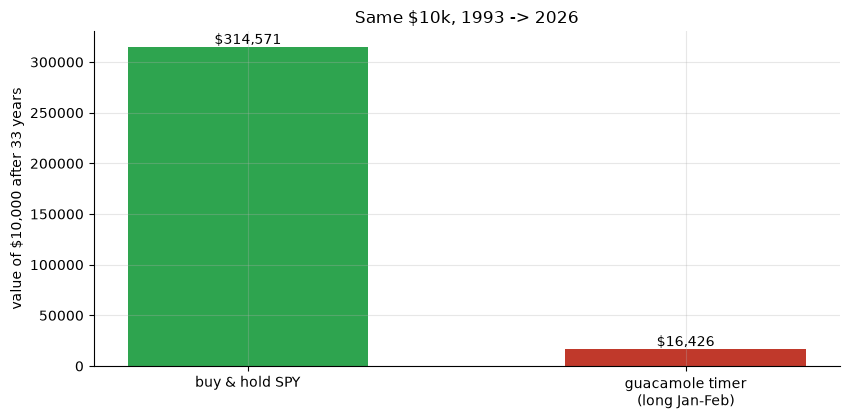

buy & hold SPY: $314,571   |   guacamole timer: $16,426


In [6]:
start = 10_000.0; yrs = R['n_months']/12
spy_end = start*(1+R['spy_cagr']/100)**yrs
timer_end = start*(1+R['timer_cagr']/100)**yrs
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.bar(['buy & hold SPY', 'guacamole timer\n(long Jan-Feb)'], [spy_end, timer_end],
       color=[GREEN, RED], width=.55)
for i,v in enumerate([spy_end, timer_end]): ax.annotate(f'${v:,.0f}',(i,v),ha='center',va='bottom')
ax.set_ylabel(f'value of $10,000 after {yrs:.0f} years')
ax.set_title('Same $10k, 1993 -> 2026'); plt.tight_layout(); plt.show()
print(f'buy & hold SPY: ${spy_end:,.0f}   |   guacamole timer: ${timer_end:,.0f}')

The index investor multiplies their money many times over doing nothing. The calendar trader — earning cash rates 10 months a year and the market's *worst* window the other two — ends up a small fraction of that. There is no execution trick that rescues a window that is negative before you even pay costs. And the one instrument that *is* the avocado trade (Calavo) can't be reliably bought on the tape at all.

## 7 · Going further 🚪

- **Pull the real avocado tape.** Our seasonal line is a cited *approximation*; USDA AMS Market News and the Hass Avocado Board publish weekly price + volume. Swap them in — the *shape* (winter-soft, summer-peak) won't move.
- **Get CVGW back.** If Calavo's history returns to the feed, re-run with the pure-play avocado equity in place of `PEP`; the placebo and timer machinery is ticker-agnostic.
- **The calendar-folklore family.** Sell-in-May, the Santa rally, the [coffee frost trade](../../307-coffee-seasonality/): a vivid, *true* story about the world that makes a *terrible* calendar trade because everyone can see the date coming ([docs/references.md](../docs/references.md)).

*Think a specific produce name (a berry grower, a lime importer) prints a real Super-Bowl seasonal net of costs? Pull its tape, run the placebo, and show it sits in the tail — not the crowd.*